In [1]:

import sys
from pathlib import Path

# Add parent directory to sys.path for modular imports
parent_dir = Path(r"A:\Github\Agentic-Ai-LangGraph-Agent")
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

In [2]:
parent_dir

WindowsPath('A:/Github/Agentic-Ai-LangGraph-Agent')

In [3]:
from nodes.search_news import SearchNewsNode
from langgraph.graph import StateGraph ,START  , END
from langgraph.checkpoint.memory import MemorySaver
from core.state import TwitterAgentState
from nodes.generate_viral_hook2 import GenerateViralHookNode
from nodes.generate_post_content2 import GeneratePostContentNode
from nodes.error_handler import ErrorHandlerNode
from nodes.human_review_news import HumanReviewNewsNode
from edges.routing import route_after_search

In [4]:
search_news = SearchNewsNode()
generate_viral_hook = GenerateViralHookNode()
generate_post_content = GeneratePostContentNode()
error_handler = ErrorHandlerNode()
human_review_news = HumanReviewNewsNode()

In [5]:
graph = StateGraph(TwitterAgentState)

In [6]:
checkpointer = MemorySaver()

In [7]:
graph.add_node("search_news" , search_news )
graph.add_node("human_review_news" , human_review_news )
graph.add_node("generate_viral_hook" , generate_viral_hook )
graph.add_node("generate_post_content" , generate_post_content )
graph.add_node("error_handler" , error_handler )

graph.add_edge(START , "search_news")
graph.add_conditional_edges("search_news" , route_after_search , {"human_review_news": "human_review_news", "error_handler": "error_handler"})
graph.add_edge("error_handler" , END)
graph.add_edge("generate_viral_hook" , END)
graph.add_edge("generate_post_content" , END)


workflow = graph.compile(checkpointer= checkpointer)

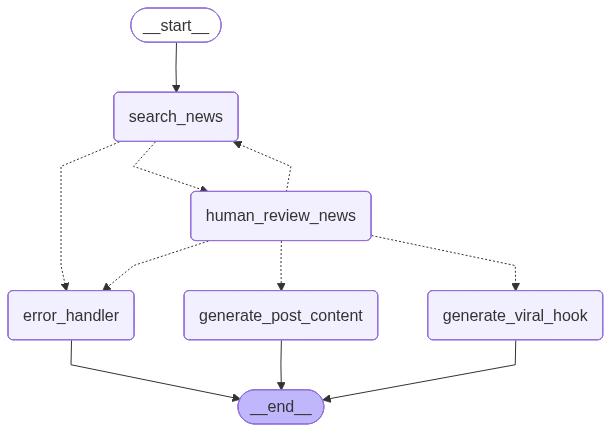

In [18]:
workflow

In [8]:
config = {"configurable": {"thread_id": "approval-123"}}

In [9]:
result = workflow.invoke({"topic" : "AI Agents 2026" , "content_type" : "thread"} , config=config)

In [10]:
result

{'topic': 'AI Agents 2026',
 'content_type': 'thread',
 'raw_news': [{'title': "What's next in AI: 7 trends to watch in 2026",
   'url': 'https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/',
   'snippet': 'AI agents will proliferate in 2026 and play a bigger role in daily work, acting more like teammates than tools, says Vasu Jakkal, corporate vice president of Microsoft Security. As organizations rely on these agents to help with tasks and decision-making, building trust in them will be essential, Jakkal says — starting with security.\n\n“Every agent should have similar security protections as humans,” she says, “to ensure agents don’t turn into ‘double agents’ carrying unchecked risk.” [...] This ',
   'source': 'news.microsoft.com',
   'published_at': 'recent'},
  {'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead

In [11]:
print(result["__interrupt__"])

[Interrupt(value={'question': 'Review the fetched news articles. Approve the ones you want to use.', 'articles': [{'index': 0, 'title': "What's next in AI: 7 trends to watch in 2026", 'source': 'news.microsoft.com', 'url': 'https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/'}, {'index': 1, 'title': "AI agents arrived in 2025 – here's what happened and the ...", 'source': 'theconversation.com', 'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'}, {'index': 2, 'title': 'Counterpoint: Meet the AI Agents of 2026 - NH Journal', 'source': 'nhjournal.com', 'url': 'https://nhjournal.com/counterpoint-meet-the-ai-agents-of-2026-ambitious-overhyped-and-still-in-training/'}, {'index': 3, 'title': 'AI Agents in 2026: From Hype to Enterprise Reality - Kore.ai', 'source': 'www.kore.ai', 'url': 'https://www.kore.ai/blog/ai-agents-in-2026-from-hype-to-enterprise-reality'}, {'index': 4, 'title'

In [12]:
interrupt_payload = result.get("__interrupt__")
if not interrupt_payload:
    print("ERROR: graph did not pause at human_review_news")
    print("workflow_status:", result.get("workflow_status"))
    print("error_message:  ", result.get("error_message"))
    exit(1)
 

In [19]:
interrupt_payload[0]

Interrupt(value={'question': 'Review the fetched news articles. Approve the ones you want to use.', 'articles': [{'index': 0, 'title': 'Counterpoint: Meet the AI Agents of 2026 - NH Journal', 'source': 'nhjournal.com', 'url': 'https://nhjournal.com/counterpoint-meet-the-ai-agents-of-2026-ambitious-overhyped-and-still-in-training/'}, {'index': 1, 'title': 'The future of AI agents: Key trends to watch in 2026 - Salesmate', 'source': 'www.salesmate.io', 'url': 'https://www.salesmate.io/blog/future-of-ai-agents/'}, {'index': 2, 'title': '7 Agentic AI Trends to Watch in 2026 - MachineLearningMastery.com', 'source': 'machinelearningmastery.com', 'url': 'https://machinelearningmastery.com/7-agentic-ai-trends-to-watch-in-2026/'}, {'index': 3, 'title': '10 Best AI Agents in 2026: Top Picks for Business & Enterprise ...', 'source': 'www.tredence.com', 'url': 'https://www.tredence.com/blog/best-ai-agents-2025'}, {'index': 4, 'title': 'AI AGENTS IN 2026: A Comparative Guide to Tools, Frameworks ..

In [13]:
interrupt_payload[0].value

{'question': 'Review the fetched news articles. Approve the ones you want to use.',
 'articles': [{'index': 0,
   'title': "What's next in AI: 7 trends to watch in 2026",
   'source': 'news.microsoft.com',
   'url': 'https://news.microsoft.com/source/features/ai/whats-next-in-ai-7-trends-to-watch-in-2026/'},
  {'index': 1,
   'title': "AI agents arrived in 2025 – here's what happened and the ...",
   'source': 'theconversation.com',
   'url': 'https://theconversation.com/ai-agents-arrived-in-2025-heres-what-happened-and-the-challenges-ahead-in-2026-272325'},
  {'index': 2,
   'title': 'Counterpoint: Meet the AI Agents of 2026 - NH Journal',
   'source': 'nhjournal.com',
   'url': 'https://nhjournal.com/counterpoint-meet-the-ai-agents-of-2026-ambitious-overhyped-and-still-in-training/'},
  {'index': 3,
   'title': 'AI Agents in 2026: From Hype to Enterprise Reality - Kore.ai',
   'source': 'www.kore.ai',
   'url': 'https://www.kore.ai/blog/ai-agents-in-2026-from-hype-to-enterprise-reali

In [14]:

# Show what interrupt() surfaced
print("\n--- interrupt payload ---")
payload = interrupt_payload[0].value
print(f"question    : {payload['question']}")
print(f"retry_count : {payload['retry_count']}")
print(f"articles    : {len(payload['articles'])} fetched")

 



--- interrupt payload ---
question    : Review the fetched news articles. Approve the ones you want to use.
retry_count : 0
articles    : 8 fetched


In [15]:
for a in payload["articles"]:
    print(f"  [{a['index']}] {a['title']}  ({a['source']})")

  [0] What's next in AI: 7 trends to watch in 2026  (news.microsoft.com)
  [1] AI agents arrived in 2025 – here's what happened and the ...  (theconversation.com)
  [2] Counterpoint: Meet the AI Agents of 2026 - NH Journal  (nhjournal.com)
  [3] AI Agents in 2026: From Hype to Enterprise Reality - Kore.ai  (www.kore.ai)
  [4] The future of AI agents: Key trends to watch in 2026 - Salesmate  (www.salesmate.io)
  [5] What to Expect From AI in 2026: Personal Agents, Mega Alliances ...  (www.goldmansachs.com)
  [6] What is your full AI Agent stack in 2026? : r/AI_Agents  (www.reddit.com)
  [7] AI agent trends 2026 report  (cloud.google.com)


In [16]:
from langgraph.types import Command

In [22]:
# Phase 2 — human picks articles and resumes
print("\n" + "=" * 60)
print("  Phase 2: approving articles 0 and 1...")
print("=" * 60)
result = workflow.invoke(
    Command(resume={"action": "approve", "approved_indices": [0, 1 ]}),
    config=config,
)
 
# Phase 3 — show final state after both gen nodes finish
print("\n" + "=" * 60)
print("  RESULTS")
print("=" * 60)
 
viral_hook   = result.get("viral_hook")
post_content = result.get("post_content") or []
final_draft  = result.get("final_draft") or []
hashtags     = result.get("hashtags") or []
cta          = result.get("cta")
 
print(f"\nviral_hook ({len(viral_hook or '')} chars):")
print(f"  {viral_hook}")
 
print(f"\npost_content ({len(post_content)} body tweets):")
for t in post_content:
    print(f"  tweet {t['tweet_number']} ({t['character_count']} chars): {t['content'][:70]}...")
 
print(f"\nhashtags : {hashtags}")
print(f"cta      : {cta}")
 
print(f"\nfinal_draft ({len(final_draft)} assembled tweets):")
for t in final_draft:
    print(f"\n  [{t['tweet_number']}] ({t['character_count']}/280 chars)")
    print(f"  {t['content']}")
 
print(f"\nworkflow_status: {result.get('workflow_status')}")


  Phase 2: approving articles 0 and 1...

  RESULTS

viral_hook (132 chars):
  Google’s AI Agent 2026 report predicts autonomous bots will handle 45% of routine dev tasks by Q3—here’s the playbook to stay ahead.

post_content (6 body tweets):
  tweet 2 (155 chars): 2/7 The AI game is changing: agents are moving from single‑prompt tool...
  tweet 3 (180 chars): 3/7 Microsoft warns that as agents become coworkers, they need the sam...
  tweet 4 (151 chars): 4/7 Google’s 2026 report, based on 3,466 execs, shows 78% expect AI ag...
  tweet 5 (160 chars): 5/7 For you, that means faster project cycles, but also a new responsi...
  tweet 6 (165 chars): 6/7 Imagine an agent that mis‑routes a security patch or leaks a clien...
  tweet 7 (212 chars): 7/7 Build a “security‑first” playbook: assign identity, enforce least‑...

hashtags : ['#AI', '#Agents', '#Security', '#TechLeadership', '#FutureOfWork']
cta      : Start drafting your AI agent security checklist today.

final_draft (7 assembled tw